In [1]:
import pandas as pd

In [2]:
base_path = r'data/smartphone_addiction'
train_path = base_path + '/' + 'train.csv'
test_path = base_path + '/' + 'test.csv'

In [3]:
import os
os.path.exists('../../' + base_path)

True

In [4]:
os.listdir()

['initial.ipynb', 'sample_submission.csv', 'test.csv', 'train.csv']

In [5]:
train_df = pd.read_csv('../../'+ train_path)

In [6]:
df = train_df.copy()

In [7]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [8]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [12]:
# Column names and types
TARGET = "addicted_label"
ID = "id"
num_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
]

cat_cols = [
    'gender',               # Male, Female, Other  
    'stress_level',         # High, Low, Medium
    'academic_work_impact'  # Yes, No
]

In [9]:
df[['gender', 'academic_work_impact']].value_counts()

gender  academic_work_impact
Male    Yes                     106532
Female  Yes                     105785
Other   Yes                     104603
Male    No                      103167
Female  No                      101749
Other   No                       98718
Name: count, dtype: int64

In [10]:
df[['gender', 'stress_level']].value_counts()

gender  stress_level
Other   High            72222
Male    High            69932
Female  High            69735
Male    Low             68191
        Medium          67935
Female  Low             67884
        Medium          66544
Other   Medium          64415
        Low             63274
Name: count, dtype: int64

In [11]:
df[['academic_work_impact', 'stress_level']].value_counts()

academic_work_impact  stress_level
Yes                   High            109871
No                    High             99490
Yes                   Low              99349
                      Medium           99100
No                    Low              97849
                      Medium           97767
Name: count, dtype: int64

In [12]:
df[['gender', 'academic_work_impact', 'stress_level']].value_counts()

gender  academic_work_impact  stress_level
Other   Yes                   High            36332
Female  Yes                   High            34562
Male    Yes                   High            34490
                              Medium          32535
                              Low             32411
Female  Yes                   Low             32390
Male    No                    Low             32344
Other   No                    High            32218
Male    No                    Medium          32041
Female  No                    Low             32024
Male    No                    High            31849
Female  Yes                   Medium          31671
        No                    High            31499
                              Medium          31431
Other   Yes                   Medium          30847
                              Low             30532
        No                    Medium          30238
                              Low             29589
Name: count, dtype: i

In [13]:
df[['gender', 'academic_work_impact', 'stress_level', TARGET]].value_counts()

gender  academic_work_impact  stress_level  addicted_label
Other   Yes                   High          1                 25405
Male    Yes                   High          1                 24992
Female  Yes                   High          1                 24302
Male    Yes                   Low           1                 23521
        No                    Low           1                 23417
        Yes                   Medium        1                 23348
        No                    High          1                 23166
                              Medium        1                 23078
Female  Yes                   Low           1                 22868
Other   No                    High          1                 22782
Female  No                    Low           1                 22660
                              High          1                 22318
        Yes                   Medium        1                 22131
        No                    Medium        1            

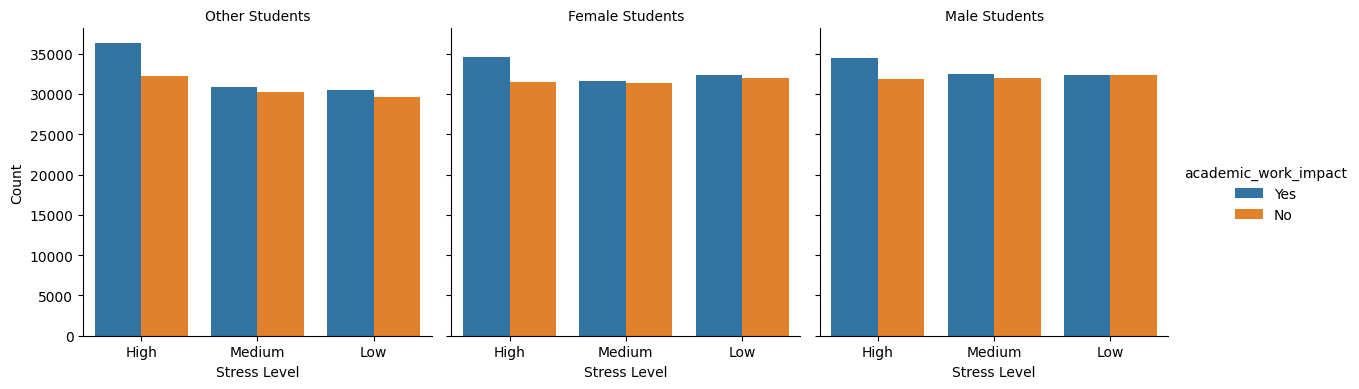

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to convert the MultiIndex Series from value_counts() into a DataFrame
df_counts = (
    df[["gender", "academic_work_impact", "stress_level"]]
    .value_counts()
    .reset_index(name="count")
)

# Create a faceted grid of bar plots
g = sns.catplot(
    data=df_counts,
    x="stress_level",
    y="count",
    hue="academic_work_impact",
    col="gender",
    kind="bar",
    height=4,
    aspect=1,
)

g.set_axis_labels("Stress Level", "Count")
g.set_titles("{col_name} Students")
plt.show()


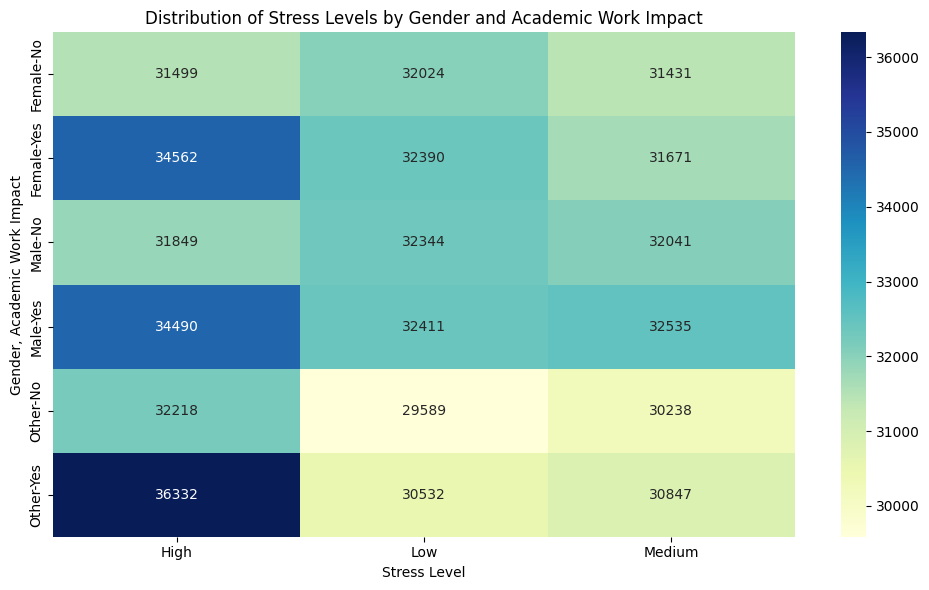

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data to create a matrix format
df_pivot = (
    df.groupby(["gender", "academic_work_impact", "stress_level"])
    .size()
    .unstack(fill_value=0)
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Distribution of Stress Levels by Gender and Academic Work Impact")
plt.ylabel("Gender, Academic Work Impact")
plt.xlabel("Stress Level")
plt.tight_layout()
plt.show()


In [10]:
import mlflow
# mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_tracking_uri("http://127.0.0.1:5000")


In [8]:
from __future__ import annotations

import inspect
import json
import logging
from copy import deepcopy
from typing import Any, Dict, List, Optional, Sequence

import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight


logger = logging.getLogger(__name__)


def train_binary_classifier_5fold(
    df: pd.DataFrame,
    feature_names: Sequence[str],
    target: str,
    description: str,
    model: Any,
    model_params: Optional[Dict[str, Any]] = None,
    experiment_name: str = "binary_classification",
    run_name: Optional[str] = None,
    n_splits: int = 5,
    random_state: int = 42,
    handle_imbalance: bool = True,
    log_model: bool = True,
    register_model_name: Optional[str] = None,
) -> Dict[str, Any]:
    """
    Generic stratified K-fold binary classification trainer.

    Supports sklearn-compatible estimators such as:

        - LightGBM LGBMClassifier
        - XGBoost XGBClassifier
        - LogisticRegression
        - TabPFNClassifier
        - Other sklearn-compatible classifiers

    MLflow autologging captures supported estimator parameters.
    Custom CV and OOF metrics are logged explicitly.

    Parameters
    ----------
    df:
        Input DataFrame.

    feature_names:
        Feature columns used for training.

    target:
        Binary target column.

    description:
        Experiment/model description.

    model:
        UNFITTED sklearn-compatible estimator.

    model_params:
        Parameters passed to model.set_params().

    experiment_name:
        MLflow experiment name.

    run_name:
        MLflow run name.

    n_splits:
        Number of CV folds.

    random_state:
        Random seed.

    handle_imbalance:
        If True, balanced sample weights are calculated independently
        for each training fold.

    log_model:
        If True, the final fitted model is logged to MLflow.

    register_model_name:
        Optional MLflow registered model name.

    Returns
    -------
    Dict[str, Any]
        Dictionary containing:

        model
        oof_predictions
        fold_metrics
        summary_metrics
        mlflow_run_id
    """

    # ==============================================================
    # 1. Validate input
    # ==============================================================

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")

    feature_names = list(feature_names)

    if not feature_names:
        raise ValueError("feature_names cannot be empty.")

    missing_features = [
        col for col in feature_names
        if col not in df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing feature columns: {missing_features}"
        )

    if target not in df.columns:
        raise ValueError(
            f"Target column '{target}' is not present in df."
        )

    if n_splits < 2:
        raise ValueError("n_splits must be at least 2.")

    # ==============================================================
    # 2. Prepare X / y
    # ==============================================================

    for i in feature_names:
        if df[i].dtype == "object":
            df[i] = df[i].astype("category")

    X = df[feature_names].copy()
    y = df[target].copy()

    # Remove rows with missing target
    valid_mask = y.notna()

    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    # ==============================================================
    # 3. Validate binary target
    # ==============================================================

    unique_classes = list(pd.unique(y))

    if len(unique_classes) != 2:
        raise ValueError(
            "Expected a binary target with exactly 2 classes. "
            f"Found: {unique_classes}"
        )

    # Stable 0/1 encoding
    class_to_int = {
        unique_classes[0]: 0,
        unique_classes[1]: 1,
    }

    y_encoded = y.map(class_to_int).astype(int)

    class_counts = y_encoded.value_counts()

    minority_count = int(class_counts.min())

    if minority_count < n_splits:
        raise ValueError(
            f"Minority class has only {minority_count} samples. "
            f"At least {n_splits} samples are required for "
            f"{n_splits}-fold CV."
        )

    logger.info(
        "Training %s with %d samples and %d features.",
        model.__class__.__name__,
        len(X),
        len(feature_names),
    )

    logger.info(
        "Class distribution: %s",
        class_counts.to_dict(),
    )

    # ==============================================================
    # 4. Prepare model
    # ==============================================================

    model_params = deepcopy(model_params or {})

    model = clone(model)

    if model_params:
        model.set_params(**model_params)

    model_name = model.__class__.__name__

    # ==============================================================
    # 5. Configure MLflow
    # ==============================================================

    mlflow.set_experiment(experiment_name)

    if run_name is None:
        run_name = f"{model_name}_5fold"

    # Simple MLflow autologging.
    #
    # log_models=False because we explicitly log only the final
    # model after all CV folds have completed.
    mlflow.autolog(
        log_models=False,
        log_input_examples=False,
        log_model_signatures=False,
        log_datasets=False,
        silent=True,
    )

    with mlflow.start_run(run_name=run_name) as run:

        logger.info(
            "Started MLflow run: %s",
            run.info.run_id,
        )

        # ==========================================================
        # 6. Log experiment metadata
        # ==========================================================

        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("task", "binary_classification")
        mlflow.set_tag(
            "cv_strategy",
            f"StratifiedKFold_{n_splits}",
        )
        mlflow.set_tag(
            "imbalance_handling",
            str(handle_imbalance),
        )

        mlflow.log_param("n_samples", len(X))
        mlflow.log_param("n_features", len(feature_names))
        mlflow.log_param("n_splits", n_splits)
        mlflow.log_param("random_state", random_state)

        mlflow.log_text(
            description,
            "description.txt",
        )

        mlflow.log_text(
            json.dumps(
                feature_names,
                indent=2,
                default=str,
            ),
            "feature_names.json",
        )

        mlflow.log_dict(
            {
                str(k): int(v)
                for k, v in class_counts.items()
            },
            "class_distribution.json",
        )

        # ==========================================================
        # 7. Log model parameters
        # ==========================================================

        try:
            params_to_log = {
                key: str(value)
                for key, value in model.get_params(
                    deep=True
                ).items()
            }

            mlflow.log_params(params_to_log)

        except Exception as exc:
            logger.warning(
                "Could not manually log model parameters: %s",
                exc,
            )

        # ==========================================================
        # 8. Stratified K-Fold
        # ==========================================================

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )

        oof_probability = np.zeros(
            len(X),
            dtype=float,
        )

        oof_prediction = np.zeros(
            len(X),
            dtype=int,
        )

        fold_metrics: List[Dict[str, Any]] = []

        # ==========================================================
        # 9. Cross-validation
        # ==========================================================

        for fold, (train_idx, valid_idx) in enumerate(
            skf.split(X, y_encoded),
            start=1,
        ):
            logger.info(
                "Starting fold %d/%d",
                fold,
                n_splits,
            )

            X_train = X.iloc[train_idx]
            X_valid = X.iloc[valid_idx]

            y_train = y_encoded.iloc[train_idx]
            y_valid = y_encoded.iloc[valid_idx]

            # ------------------------------------------------------
            # Calculate imbalance weights ONLY from training data.
            # ------------------------------------------------------

            sample_weight = None

            if handle_imbalance:
                sample_weight = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train,
                )

            # ------------------------------------------------------
            # Fresh model for each fold
            # ------------------------------------------------------

            fold_model = clone(model)

            # ------------------------------------------------------
            # Check whether estimator supports sample_weight
            # ------------------------------------------------------

            fit_kwargs: Dict[str, Any] = {}

            if handle_imbalance:
                try:
                    fit_signature = inspect.signature(
                        fold_model.fit
                    )

                    parameters = fit_signature.parameters

                    accepts_sample_weight = (
                        "sample_weight" in parameters
                        or any(
                            param.kind
                            == inspect.Parameter.VAR_KEYWORD
                            for param in parameters.values()
                        )
                    )

                    if accepts_sample_weight:
                        fit_kwargs["sample_weight"] = sample_weight
                    else:
                        logger.warning(
                            "%s does not appear to support "
                            "sample_weight. Continuing without "
                            "sample weights.",
                            model_name,
                        )

                except (TypeError, ValueError):
                    logger.warning(
                        "Could not inspect %s.fit(). "
                        "Continuing without sample weights.",
                        model_name,
                    )

            # ------------------------------------------------------
            # Fit fold
            # ------------------------------------------------------

            fold_model.fit(
                X_train,
                y_train,
                **fit_kwargs,
            )

            # ------------------------------------------------------
            # Predict probabilities
            # ------------------------------------------------------

            if not hasattr(
                fold_model,
                "predict_proba",
            ):
                raise TypeError(
                    f"{model_name} does not implement predict_proba(). "
                    "This trainer requires probability predictions "
                    "for ROC-AUC, PR-AUC and log-loss."
                )

            valid_probability = (
                fold_model.predict_proba(X_valid)[:, 1]
            )

            valid_prediction = (
                valid_probability >= 0.5
            ).astype(int)

            # ------------------------------------------------------
            # Store OOF predictions
            # ------------------------------------------------------

            oof_probability[valid_idx] = valid_probability
            oof_prediction[valid_idx] = valid_prediction

            # ------------------------------------------------------
            # Fold metrics
            # ------------------------------------------------------

            fold_result = {
                "fold": fold,

                "roc_auc": roc_auc_score(
                    y_valid,
                    valid_probability,
                ),

                "pr_auc": average_precision_score(
                    y_valid,
                    valid_probability,
                ),

                "accuracy": accuracy_score(
                    y_valid,
                    valid_prediction,
                ),

                "balanced_accuracy": balanced_accuracy_score(
                    y_valid,
                    valid_prediction,
                ),

                "precision": precision_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "recall": recall_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "f1": f1_score(
                    y_valid,
                    valid_prediction,
                    zero_division=0,
                ),

                "log_loss": log_loss(
                    y_valid,
                    valid_probability,
                    labels=[0, 1],
                ),
            }

            fold_metrics.append(fold_result)

            # ------------------------------------------------------
            # Log fold metrics
            # ------------------------------------------------------

            mlflow.log_metrics(
                {
                    f"fold_{fold}_{metric}": float(value)
                    for metric, value in fold_result.items()
                    if metric != "fold"
                }
            )

            logger.info(
                "Fold %d/%d - ROC-AUC: %.4f | PR-AUC: %.4f | "
                "F1: %.4f",
                fold,
                n_splits,
                fold_result["roc_auc"],
                fold_result["pr_auc"],
                fold_result["f1"],
            )

        # ==========================================================
        # 10. OOF metrics
        # ==========================================================

        oof_metrics = {
            "oof_roc_auc": roc_auc_score(
                y_encoded,
                oof_probability,
            ),

            "oof_pr_auc": average_precision_score(
                y_encoded,
                oof_probability,
            ),

            "oof_accuracy": accuracy_score(
                y_encoded,
                oof_prediction,
            ),

            "oof_balanced_accuracy": balanced_accuracy_score(
                y_encoded,
                oof_prediction,
            ),

            "oof_precision": precision_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_recall": recall_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_f1": f1_score(
                y_encoded,
                oof_prediction,
                zero_division=0,
            ),

            "oof_log_loss": log_loss(
                y_encoded,
                oof_probability,
                labels=[0, 1],
            ),
        }

        mlflow.log_metrics(
            {
                key: float(value)
                for key, value in oof_metrics.items()
            }
        )

        logger.info(
            "OOF ROC-AUC: %.4f | OOF PR-AUC: %.4f | OOF F1: %.4f",
            oof_metrics["oof_roc_auc"],
            oof_metrics["oof_pr_auc"],
            oof_metrics["oof_f1"],
        )

        # ==========================================================
        # 11. CV mean/std metrics
        # ==========================================================

        fold_metrics_df = pd.DataFrame(
            fold_metrics
        )

        metric_names = [
            "roc_auc",
            "pr_auc",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "log_loss",
        ]

        for metric in metric_names:

            mean_value = fold_metrics_df[metric].mean()

            std_value = fold_metrics_df[metric].std()

            mlflow.log_metric(
                f"cv_mean_{metric}",
                float(mean_value),
            )

            mlflow.log_metric(
                f"cv_std_{metric}",
                float(std_value),
            )

        # ==========================================================
        # 12. Log CV results
        # ==========================================================

        mlflow.log_table(
            fold_metrics_df,
            "fold_metrics.json",
        )

        # ==========================================================
        # 13. OOF predictions
        # ==========================================================

        oof_df = df.loc[valid_mask].copy()
        oof_df = oof_df.reset_index(drop=True)

        oof_df["y_true"] = y_encoded.values

        oof_df["oof_probability"] = oof_probability

        oof_df["oof_prediction"] = oof_prediction

        mlflow.log_table(
            oof_df[
                [
                    target,
                    "y_true",
                    "oof_probability",
                    "oof_prediction",
                ]
            ],
            "oof_predictions.json",
        )

        # ==========================================================
        # 14. Train final model on ALL data
        # ==========================================================

        logger.info(
            "Training final %s model on all %d samples.",
            model_name,
            len(X),
        )

        final_model = clone(model)

        final_fit_kwargs: Dict[str, Any] = {}

        if handle_imbalance:

            full_sample_weight = compute_sample_weight(
                class_weight="balanced",
                y=y_encoded,
            )

            try:
                fit_signature = inspect.signature(
                    final_model.fit
                )

                parameters = fit_signature.parameters

                accepts_sample_weight = (
                    "sample_weight" in parameters
                    or any(
                        param.kind
                        == inspect.Parameter.VAR_KEYWORD
                        for param in parameters.values()
                    )
                )

                if accepts_sample_weight:
                    final_fit_kwargs["sample_weight"] = (
                        full_sample_weight
                    )
                else:
                    logger.warning(
                        "%s does not support sample_weight. "
                        "Final model will be trained without it.",
                        model_name,
                    )

            except (TypeError, ValueError):
                logger.warning(
                    "Could not inspect final model fit(). "
                    "Training without sample weights."
                )

        final_model.fit(
            X,
            y_encoded,
            **final_fit_kwargs,
        )

        # ==========================================================
        # 15. Log final model
        # ==========================================================

        if log_model:

            logger.info(
                "Logging final model to MLflow."
            )

            model_output = final_model.predict_proba(X)

            signature = mlflow.models.infer_signature(
                X,
                model_output,
            )

            mlflow.sklearn.log_model(
                final_model,
                name="model",
                signature=signature,
                registered_model_name=register_model_name,
                serialization_format="cloudpickle",
            )

        # ==========================================================
        # 16. Summary
        # ==========================================================

        summary_metrics = {
            **oof_metrics,

            **{
                f"cv_mean_{metric}": float(
                    fold_metrics_df[metric].mean()
                )
                for metric in metric_names
            },

            **{
                f"cv_std_{metric}": float(
                    fold_metrics_df[metric].std()
                )
                for metric in metric_names
            },
        }

        result = {
            "model": final_model,
            "oof_predictions": oof_df,
            "fold_metrics": fold_metrics_df,
            "summary_metrics": summary_metrics,
            "mlflow_run_id": run.info.run_id,
        }

        logger.info(
            "Training completed successfully. "
            "MLflow run_id=%s",
            run.info.run_id,
        )

    return result

In [9]:
with_null_df = train_df.copy()

In [27]:
from lightgbm import LGBMClassifier


result = train_binary_classifier_5fold(
    df=with_null_df,
    feature_names = num_cols + cat_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 500,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000

2026/08/09 23:16:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/7938ff3ab5c940d698b0978bb33069e4
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [28]:
result

{'model': LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=500,
                n_jobs=-1, random_state=42, subsample=0.8),
 'oof_predictions':             id   age  daily_screen_time_hours  social_media_hours  \
 0            0  24.0                      NaN                1.83   
 1            1  19.0                     5.97                1.08   
 2            2  18.0                     5.09                 NaN   
 3            3  21.0                     6.42                1.26   
 4            4  26.0                    11.20                1.87   
 ...        ...   ...                      ...                 ...   
 691364  691364  22.0                    10.78                3.25   
 691365  691365  20.0                     3.45                1.86   
 691366  691366   NaN                      NaN                 NaN   
 691367  691367  22.0                    11.78                3.69   
 691368  691368  21.0                     5.64                1.03

In [ ]:
from lightgbm import LGBMClassifier


result = train_binary_classifier_5fold(
    df=with_null_df,
    feature_names = num_cols + cat_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 1500,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

2026/08/09 23:31:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/e28227964fbf4a429df0a1bd13035f66
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [18]:
test = pd.read_csv('../../'+ test_path)


In [35]:
test = pd.read_csv('../../'+ test_path)
for i in num_cols + cat_cols:
    if test[i].dtype == "object":
        test[i] = test[i].astype("category")
test[TARGET] = result["model"].predict_proba(test[num_cols + cat_cols])[:, 1]
test[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission000.csv', index=False)

In [38]:
test[["id", TARGET]]

,id,addicted_label
0,691369,0.003143
1,691370,0.090843
2,691371,0.083268
3,691372,0.036619
4,691373,0.007815
...,...,...
296297,987666,0.000005
296298,987667,0.169593
296299,987668,0.911795
296300,987669,0.566616


In [40]:
xx = result["model"].predict_proba(test[num_cols + cat_cols])[:,0]
zz = test.copy()
zz[TARGET] = xx
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission001.csv', index=False)

In [41]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [42]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
xx["weekday_screen_time"] = xx['daily_screen_time_hours'] - xx["weekend_screen_time"]
new_cols = ["weekday_screen_time"]


result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="LightGBM binary classifier for smartphone addiction",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 2000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold",
)

2026/08/09 23:58:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold at: http://localhost:5000/#/experiments/1/runs/2e8fe79491874f478d710b6df1e726a4
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [46]:
zz = test.copy()
zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz["weekend_screen_time"]
xx_preds = result["model"].predict_proba(zz[num_cols + cat_cols + new_cols])[:,0]
zz[TARGET] = xx_preds
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission002.csv', index=False)

In [21]:
num_cols, cat_cols 
#, new_cols

(['age',
  'daily_screen_time_hours',
  'social_media_hours',
  'gaming_hours',
  'work_study_hours',
  'sleep_hours',
  'notifications_per_day',
  'app_opens_per_day',
  'weekend_screen_time'],
 ['gender', 'stress_level', 'academic_work_impact'])

In [ ]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
# xx["weekday_screen_time"] = xx['daily_screen_time_hours'] - xx["weekend_screen_time"]
# xx["weekend_screen_time"] = xx['daily_screen_time_hours'] - xx['weekday_screen_time']
# xx[""] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] - xx['work_study_hours'] - xx['sleep_hours']
# xx["other_screen_time"] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] # - xx['work_study_hours'] - xx['sleep_hours']
xx["screen_time_by_sleep_ratio"] = xx['daily_screen_time_hours'] **(0.5) / (xx['sleep_hours'] + 1e-5)  # Avoid division by zero

new_cols = [
    # "other_screen_time", 
    "screen_time_by_sleep_ratio"
]


result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="Adding other_screen_time and screen_time_by_sleep_ratio",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 2000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold, screen_time_by_sleep_ratio",
)

In [16]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
xx["weekday_screen_time"] = xx['daily_screen_time_hours'] - xx["weekend_screen_time"]
# xx["weekend_screen_time"] = xx['daily_screen_time_hours'] - xx['weekday_screen_time']
# xx[""] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] - xx['work_study_hours'] - xx['sleep_hours']
# xx["other_screen_time"] = xx['daily_screen_time_hours'] - xx['gaming_hours'] - xx['social_media_hours'] # - xx['work_study_hours'] - xx['sleep_hours']
# xx["screen_time_by_sleep_ratio"] = xx['daily_screen_time_hours'] **(0.5) / (xx['sleep_hours'] + 1e-5)  # Avoid division by zero
xx['notif_by_opens'] = 1/(xx["notifications_per_day"] / (1e-5 + xx['app_opens_per_day']))
new_cols = [
    "weekday_screen_time",
    # "other_screen_time", 
    # "screen_time_by_sleep_ratio",
    "notif_by_opens",
]


result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="weekday screen time + notification by app opens",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 2000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            # "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="lgbm_5fold, screen_time_by_sleep_ratio",
)

[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2213
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2211
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 13
[LightGBM] [

2026/08/15 21:51:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm_5fold, screen_time_by_sleep_ratio at: http://127.0.0.1:5000/#/experiments/1/runs/8edc7372c11344acbb0778dcfc1fadcc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [21]:
zz = test.copy()
for i in num_cols + cat_cols:
    if zz[i].dtype == "object":
        zz[i] = zz[i].astype("category")
# zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz["weekend_screen_time"]
zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz['gaming_hours'] - zz['social_media_hours']
xx_preds = result["model"].predict_proba(zz[num_cols + cat_cols + new_cols])[:,0]
zz[TARGET] = xx_preds
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission004.csv', index=False)

In [39]:
result.get("model").feature_name_, #result.get("model").feature_importances_

(['age',
  'daily_screen_time_hours',
  'social_media_hours',
  'gaming_hours',
  'work_study_hours',
  'sleep_hours',
  'notifications_per_day',
  'app_opens_per_day',
  'weekend_screen_time',
  'gender',
  'stress_level',
  'academic_work_impact',
  'weekday_screen_time',
  'other_screen_time'],)

In [40]:
num_cols + cat_cols + new_cols

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact',
 'weekday_screen_time',
 'other_screen_time']

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

def evaluate_new_feature(df, feature_col, target_col, is_classification=True):
    """
    Evaluates a new feature's potential and plots its distribution 
    without training a machine learning model.
    
    Parameters:
    df (pd.DataFrame): The dataframe containing your data.
    feature_col (str): Name of the newly engineered feature column.
    target_col (str): Name of the target variable column.
    is_classification (bool): True if classification task, False if regression.
    """
    # 1. Isolate datasets and handle any internal nulls for calculation
    temp_df = df[[feature_col, target_col]].dropna()
    X_feature = temp_df[[feature_col]]
    y_target = temp_df[target_col]
    
    # 2. Calculate Mutual Information (captures non-linear tree relationships)
    if is_classification:
        mi_score = mutual_info_classif(X_feature, y_target, random_state=42)[0]
    else:
        mi_score = mutual_info_regression(X_feature, y_target, random_state=42)[0]
        
    # 3. Check for redundancy (linear correlation with all other numerical columns)
    numeric_df = df.select_dtypes(include=[np.number])
    if feature_col in numeric_df.columns:
        corr_matrix = numeric_df.corr()[feature_col].abs()
        # Drop self-correlation and target correlation to find the closest existing feature
        corr_with_others = corr_matrix.drop(labels=[feature_col, target_col], errors='ignore')
        max_corr_feature = corr_with_others.idxmax()
        max_corr_value = corr_with_others.max()
    else:
        max_corr_feature = "N/A (Feature is categorical)"
        max_corr_value = 0.0

    # 4. Generate summary report
    print("="*50)
    print(f"FEATURE EVALUATION REPORT FOR: '{feature_col}'")
    print("="*50)
    print(f"• Mutual Information Score: {mi_score:.4f}")
    print(f"  (Higher is better. > 0.01 suggests predictive power; > 0.1 is strong)")
    print("-"*50)
    print(f"• Most Redundant With:      '{max_corr_feature}'")
    print(f"• Maximum Correlation Value: {max_corr_value:.4f}")
    print(f"  (Lower is better. > 0.85 indicates the feature is highly redundant)")
    print("="*50)
    
    # Text recommendation
    if mi_score > 0.02 and max_corr_value < 0.80:
        print("RECOMMENDATION: Highly Promising. Low redundancy and clear target relationship.")
    elif max_corr_value >= 0.85:
        print("RECOMMENDATION: Likely Redundant. Very high correlation with an existing feature.")
    else:
        print("RECOMMENDATION: Weak or Borderline. Check for weak relationships or data leaks.")
    print("="*50)

    # 5. Visualizing the feature distribution conditional on target
    plt.figure(figsize=(10, 5))
    
    if is_classification:
        # Density distribution per class
        sns.kdeplot(data=df, x=feature_col, hue=target_col, common_norm=False, fill=True, palette='Set1', alpha=0.4)
        plt.title(f'Distribution of "{feature_col}" by Class (MI: {mi_score:.4f})')
        plt.ylabel('Density')
    else:
        # Scatter relationship for regression
        sns.scatterplot(data=df, x=feature_col, y=target_col, alpha=0.5, color='teal')
        sns.regplot(data=df, x=feature_col, y=target_col, scatter=False, color='red')
        plt.title(f'Scatter Plot of "{feature_col}" vs Target (MI: {mi_score:.4f})')
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return {"mutual_information": mi_score, "max_correlation": max_corr_value}



In [15]:
with_null_df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


FEATURE EVALUATION REPORT FOR: 'notif_by_opens'
• Mutual Information Score: 0.1705
  (Higher is better. > 0.01 suggests predictive power; > 0.1 is strong)
--------------------------------------------------
• Most Redundant With:      'app_opens_per_day'
• Maximum Correlation Value: 0.6674
  (Lower is better. > 0.85 indicates the feature is highly redundant)
RECOMMENDATION: Highly Promising. Low redundancy and clear target relationship.


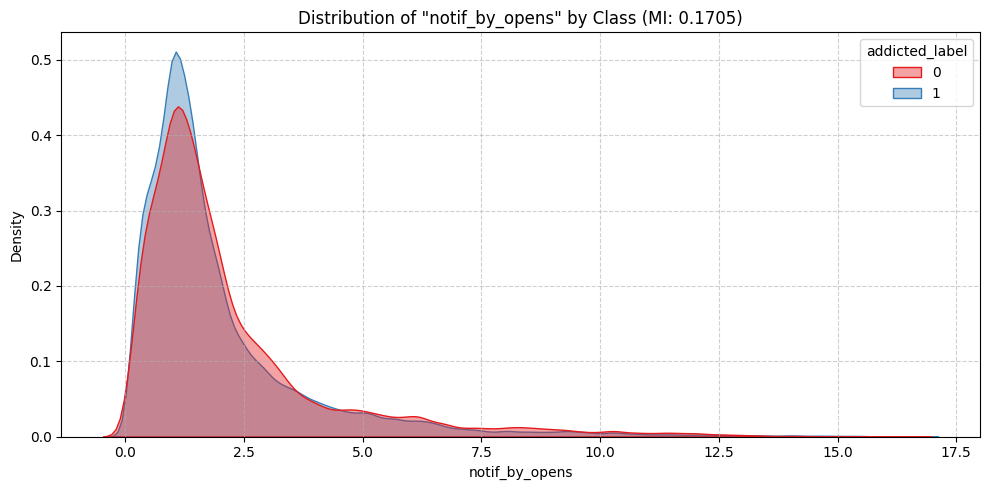

In [16]:
eda = train_df.copy()
# ==========================================
# TEST RUN: Generating mock data to run script
# =================================


# Create a new engineered feature column (Interactive Feature)
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda["weekend_screen_time"]
# eda[new_cols[0]] = eda['daily_screen_time_hours'] - eda['gaming_hours'] - eda['social_media_hours']
eda["notif_by_opens"] =  eda["notifications_per_day"]/(eda['app_opens_per_day'] + 1e-5)


# Execute function
metrics = evaluate_new_feature(
    df=eda, 
    feature_col='notif_by_opens', 
    target_col=TARGET, 
    is_classification=True
)


Train:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64

Validation:
addicted_label
1    0.709425
0    0.290575
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2212
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
Training until validation scores don't improve for 1000 rounds
[1000]	train's binary_logloss: 0.245426	valid's binary_logloss: 0.249387
[2000]	train's binary_logloss: 0.229543	valid's binary_logloss: 0.235751
[3000]	train's binary_logloss: 0.221851	valid's binary_loglo

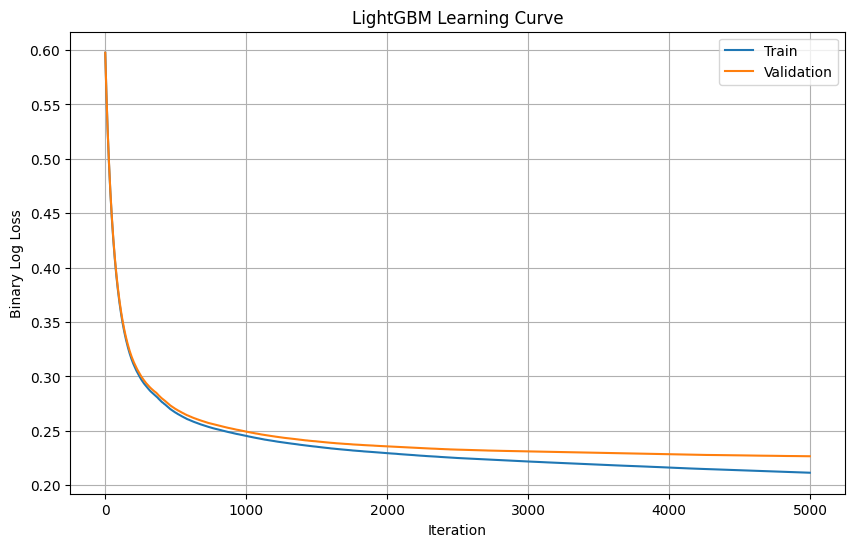

Best iteration: 5000
Best validation loss: 0.22668354209290723


In [21]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt

X = xx[num_cols + cat_cols + new_cols]
y = xx[TARGET]

# Stratified split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_valid.value_counts(normalize=True))


model = LGBMClassifier(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_valid, y_valid),
    ],
    eval_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(1000),
        lgb.log_evaluation(1000),
    ],
)

# Plot loss curve
results = model.evals_result_

plt.figure(figsize=(10, 6))

plt.plot(
    results["train"]["binary_logloss"],
    label="Train",
)

plt.plot(
    results["valid"]["binary_logloss"],
    label="Validation",
)

plt.xlabel("Iteration")
plt.ylabel("Binary Log Loss")
plt.title("LightGBM Learning Curve")
plt.legend()
plt.grid()
plt.show()

print("Best iteration:", model.best_iteration_)
print("Best validation loss:", model.best_score_["valid"]["binary_logloss"])

🏃 View run sneaky-ox-27 at: http://localhost:5000/#/experiments/1/runs/fa6179f41a3f4778a13eadd126e4a61e
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run clean-wolf-805 at: http://localhost:5000/#/experiments/1/runs/2f2d273fee7247d29f152d62778ec550
🧪 View experiment at: http://localhost:5000/#/experiments/1
FEATURE EVALUATION REPORT FOR: 'other_screen_time'
• Mutual Information Score: 0.0993
  (Higher is better. > 0.01 suggests predictive power; > 0.1 is strong)
--------------------------------------------------
• Most Redundant With:      'daily_screen_time_hours'
• Maximum Correlation Value: 0.7886
  (Lower is better. > 0.85 indicates the feature is highly redundant)
RECOMMENDATION: Highly Promising. Low redundancy and clear target relationship.


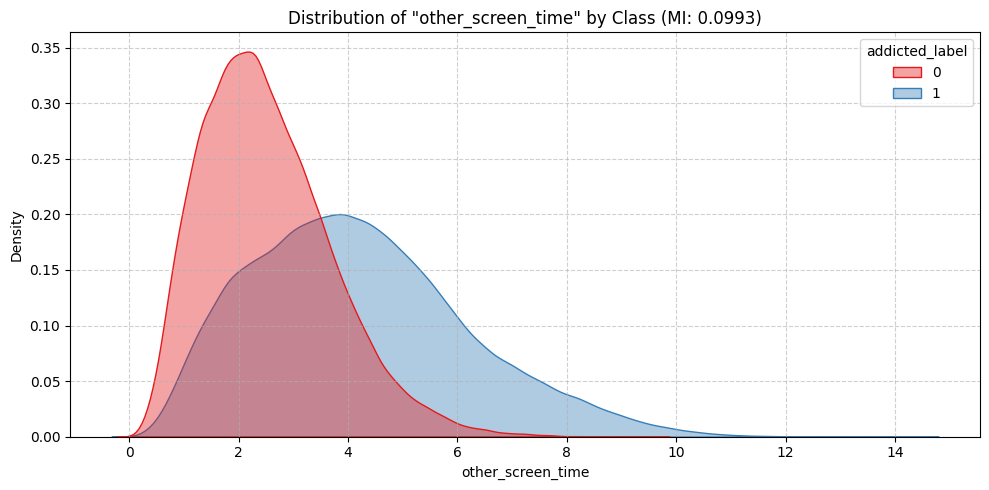

In [25]:
eda = train_df.copy()
# ==========================================
# TEST RUN: Generating mock data to run script
# =================================


# Create a new engineered feature column (Interactive Feature)
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda["weekend_screen_time"]
eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda['gaming_hours'] - eda['social_media_hours']

# Execute function
metrics = evaluate_new_feature(
    df=eda, 
    feature_col='other_screen_time', 
    target_col=TARGET, 
    is_classification=True
)


In [26]:
eda.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label',
       'other_screen_time'],
      dtype='object')

🏃 View run brawny-gnat-972 at: http://localhost:5000/#/experiments/1/runs/e23ee0f810784cb885b458fa049f470c
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run abundant-colt-346 at: http://localhost:5000/#/experiments/1/runs/7444ae2d7e814e4db7f81008fc9f9d1b
🧪 View experiment at: http://localhost:5000/#/experiments/1
FEATURE EVALUATION REPORT FOR: 'screen_time_by_sleep_ratio'
• Mutual Information Score: 0.1910
  (Higher is better. > 0.01 suggests predictive power; > 0.1 is strong)
--------------------------------------------------
• Most Redundant With:      'daily_screen_time_hours'
• Maximum Correlation Value: 0.6915
  (Lower is better. > 0.85 indicates the feature is highly redundant)
RECOMMENDATION: Highly Promising. Low redundancy and clear target relationship.


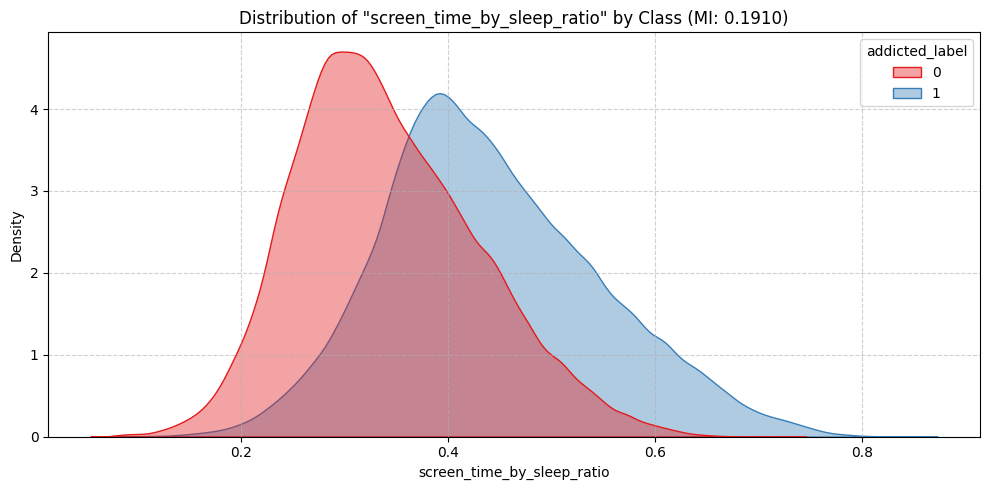

In [28]:
eda = train_df.copy()
# ==========================================
# TEST RUN: Generating mock data to run script
# =================================


# Create a new engineered feature column (Interactive Feature)
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda["weekend_screen_time"]
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda['gaming_hours'] - eda['social_media_hours']
eda["screen_time_by_sleep_ratio"] = eda['daily_screen_time_hours'] **(0.5) / (eda['sleep_hours'] + 1e-5)  # Avoid division by zero
# Execute function
metrics = evaluate_new_feature(
    df=eda, 
    feature_col='screen_time_by_sleep_ratio', 
    target_col=TARGET, 
    is_classification=True
)


In [ ]:
# Lets begin playing around

In [22]:
for col in xx.columns:
    if xx[col].isna().any():
        print(
            col,
            xx.groupby(TARGET)[col].apply(lambda x: x.isna().mean())
        )

age addicted_label
0    0.041270
1    0.042078
Name: age, dtype: float64
daily_screen_time_hours addicted_label
0    0.137749
1    0.139010
Name: daily_screen_time_hours, dtype: float64
social_media_hours addicted_label
0    0.193818
1    0.193808
Name: social_media_hours, dtype: float64
gaming_hours addicted_label
0    0.182752
1    0.183714
Name: gaming_hours, dtype: float64
work_study_hours addicted_label
0    0.074203
1    0.074644
Name: work_study_hours, dtype: float64
sleep_hours addicted_label
0    0.063461
1    0.064695
Name: sleep_hours, dtype: float64
notifications_per_day addicted_label
0    0.097479
1    0.097867
Name: notifications_per_day, dtype: float64
app_opens_per_day addicted_label
0    0.115389
1    0.117293
Name: app_opens_per_day, dtype: float64
weekend_screen_time addicted_label
0    0.161403
1    0.162369
Name: weekend_screen_time, dtype: float64
gender addicted_label
0    0.042087
1    0.041957
Name: gender, dtype: float64
stress_level addicted_label
0    0.079

In [23]:
missing_corr = {}

for col in num_cols:
    if xx[col].isna().any():
        flag = xx[col].isna().astype(int)

        corr = xx[num_cols].corrwith(flag)

        missing_corr[col] = corr.abs().sort_values(
            ascending=False
        )

for col, corr in missing_corr.items():
    print(f"\nMissingness of: {col}")
    print(corr.head(5))

d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\n


Missingness of: age
daily_screen_time_hours    0.002251
weekend_screen_time        0.002127
notifications_per_day      0.001408
social_media_hours         0.000892
sleep_hours                0.000774
dtype: float64

Missingness of: daily_screen_time_hours
age                    0.026335
work_study_hours       0.003223
weekend_screen_time    0.002645
gaming_hours           0.002249
app_opens_per_day      0.002000
dtype: float64

Missingness of: social_media_hours
age                        0.028593
app_opens_per_day          0.002351
daily_screen_time_hours    0.001493
weekend_screen_time        0.000894
sleep_hours                0.000863
dtype: float64

Missingness of: gaming_hours
age                        0.028532
weekend_screen_time        0.002772
work_study_hours           0.002007
daily_screen_time_hours    0.001956
notifications_per_day      0.000983
dtype: float64

Missingness of: work_study_hours
age                        0.015135
notifications_per_day      0.002553
gaming

d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [24]:
for col in num_cols:
    if col != "age" and xx[col].isna().any():
        print(
            col,
            "P(other missing | age missing) =",
            xx.loc[xx["age"].isna(), col].isna().mean(),
            "P(other missing | age observed) =",
            xx.loc[xx["age"].notna(), col].isna().mean(),
        )

daily_screen_time_hours P(other missing | age missing) = 0.18331086453040202 P(other missing | age observed) = 0.13669313447255602
social_media_hours P(other missing | age missing) = 0.24522105845345502 P(other missing | age observed) = 0.19156602862146005
gaming_hours P(other missing | age missing) = 0.2346434373811746 P(other missing | age observed) = 0.1811982972042751
work_study_hours P(other missing | age missing) = 0.09824051989353244 P(other missing | age observed) = 0.07347986232715416
sleep_hours P(other missing | age missing) = 0.08482837291299389 P(other missing | age observed) = 0.06344121731779481
notifications_per_day P(other missing | age missing) = 0.12499567907635936 P(other missing | age observed) = 0.09656421713664634
app_opens_per_day P(other missing | age missing) = 0.14981506446818071 P(other missing | age observed) = 0.11529497011050058
weekend_screen_time P(other missing | age missing) = 0.21113761277610701 P(other missing | age observed) = 0.1599465611979953


In [29]:
from lightgbm import LGBMClassifier

xx = with_null_df.copy()
xx["missing_count"] = xx[num_cols + cat_cols].isna().sum(axis=1)
new_cols = [
    # "missing_count",

]

print("Starting training")
result = train_binary_classifier_5fold(
    df=xx,
    feature_names = num_cols + cat_cols + new_cols,
    target=TARGET,
    description="Baseline run for all other runs",
    model=LGBMClassifier(),
        model_params={
            "n_estimators": 5000,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "n_jobs": -1,
            # "verbose": -1,
        },
    experiment_name="Smartphone_Addiction_Classification",
    run_name="Baseline Model",
)

Starting training
[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 160716, number of negative: 392379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 553095, number of used feature

2026/08/15 23:46:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Baseline Model at: http://127.0.0.1:5000/#/experiments/1/runs/96b4b2cc928c49018724c6f57438a91f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [27]:
test = pd.read_csv('../../' + test_path)

In [31]:
zz = test.copy()
for i in num_cols + cat_cols:
    if zz[i].dtype == "object":
        zz[i] = zz[i].astype("category")
# zz[new_cols[0]] = zz['daily_screen_time_hours'] - zz["weekend_screen_time"]
# zz[new_cols[0]] = zz[num_cols + cat_cols].isna().sum(axis=1)
xx_preds = result["model"].predict_proba(zz[num_cols + cat_cols + new_cols])[:,0]
zz[TARGET] = xx_preds
zz[["id", TARGET]].to_csv('../../'+ base_path + '/' + 'submission006.csv', index=False)

In [ ]:
eda = train_df.copy()
# ==========================================
# TEST RUN: Generating mock data to run script
# =================================


# Create a new engineered feature column (Interactive Feature)
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda["weekend_screen_time"]
# eda["other_screen_time"] = eda['daily_screen_time_hours'] - eda['gaming_hours'] - eda['social_media_hours']
# eda["screen_time_by_sleep_ratio"] = eda['daily_screen_time_hours'] **(0.5) / (eda['sleep_hours'] + 1e-5)  # Avoid division by zero
eda[""]
# Execute function
metrics = evaluate_new_feature(
    df=eda, 
    feature_col='screen_time_by_sleep_ratio', 
    target_col=TARGET, 
    is_classification=True
)

In [32]:
from sklearn.metrics import roc_auc_score

for col in num_cols:

    x = df[col].fillna(df[col].median())

    auc = roc_auc_score(df["addicted_label"], x)

    # If lower values indicate addiction, flip it
    auc = max(auc, 1 - auc)

    print(f"{col:35} AUC = {auc:.3f}")

age                                 AUC = 0.502
daily_screen_time_hours             AUC = 0.865
social_media_hours                  AUC = 0.818
gaming_hours                        AUC = 0.609
work_study_hours                    AUC = 0.649
sleep_hours                         AUC = 0.525
notifications_per_day               AUC = 0.508
app_opens_per_day                   AUC = 0.538
weekend_screen_time                 AUC = 0.850


In [35]:
df.groupby("addicted_label")[
    [
        "daily_screen_time_hours",
        "social_media_hours",
        "gaming_hours",
        "sleep_hours",
        "notifications_per_day",
        "app_opens_per_day",
        "weekend_screen_time",
        # "stress_level",
        # "other_screen_time"
    ]
].agg(["mean", "median", "std"])

daily_screen_time_hours                  social_media_hours  \
                                  mean median       std               mean   
addicted_label                                                               
0                             5.042929   5.04  1.620399           1.376144   
1                             8.706523   9.07  2.337327           2.919495   

                                gaming_hours                  sleep_hours  \
               median       std         mean median       std        mean   
addicted_label                                                              
0                1.29  0.739717     1.159677   1.07  0.736580    6.722321   
1                2.82  1.235099     1.582119   1.48  0.978345    6.837970   

                ...           notifications_per_day                    \
                ...       std                  mean median        std   
addicted_label  ...                                                     
0               ...  1.239769            147.087661  154.0  65.979989   
1               ...  1.230772            145.406142  150.0  65.885794   

               app_opens_per_day                   weekend_screen_time         \
                            mean median        std                mean median   
addicted_label                                                                  
0                      97.871440   99.0  47.384791            6.848920   6.82   
1                     104.592844  109.0  48.246055           10.558729  10.79   

                          
                     std  
addicted_label            
0               1.756948  
1               2.496676  

[2 rows x 21 columns]

In [37]:
from scipy.stats import mannwhitneyu

features = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    # "stress_level",
    # "other_screen_time"
]

for col in features:
    a = df.loc[df["addicted_label"] == 0, col].dropna()
    b = df.loc[df["addicted_label"] == 1, col].dropna()

    stat, p = mannwhitneyu(a, b, alternative="two-sided")

    print(col, "p =", p)

from scipy.stats import ttest_ind

for col in features:
    a = df.loc[df["addicted_label"] == 0, col].dropna()
    b = df.loc[df["addicted_label"] == 1, col].dropna()

    pooled_std = np.sqrt(
        ((len(a)-1)*a.var() + (len(b)-1)*b.var()) /
        (len(a)+len(b)-2)
    )

    d = (b.mean() - a.mean()) / pooled_std

    print(f"{col:35} Cohen's d = {d:.3f}")

daily_screen_time_hours p = 0.0
social_media_hours p = 0.0
gaming_hours p = 0.0
sleep_hours p = 6.246208666836765e-255
notifications_per_day p = 1.6852825339936625e-22
app_opens_per_day p = 0.0
weekend_screen_time p = 0.0
daily_screen_time_hours             Cohen's d = 1.701
social_media_hours                  Cohen's d = 1.385
gaming_hours                        Cohen's d = 0.462
sleep_hours                         Cohen's d = 0.094
notifications_per_day               Cohen's d = -0.026
app_opens_per_day                   Cohen's d = 0.140
weekend_screen_time                 Cohen's d = 1.609


<Axes: xlabel='app_opens_per_day', ylabel='Density'>

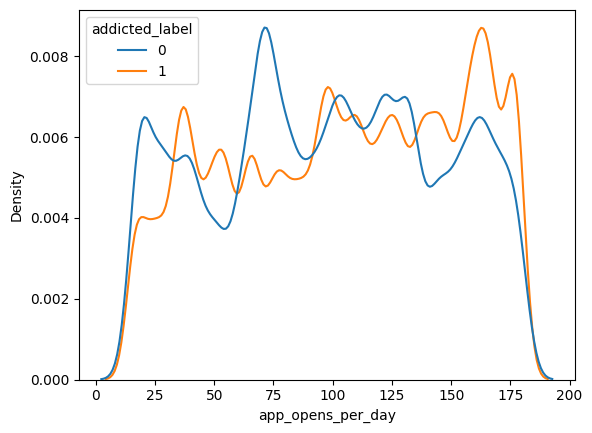

In [40]:
import seaborn as sns
sns.kdeplot(
    data=with_null_df,
    x="app_opens_per_day",
    hue="addicted_label",
    common_norm=False
)